# 08_优化算法-贝叶斯优化

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天和大家一起讨论一下贝叶斯优化\~

首先，咱们来说说基本的定义，贝叶斯优化是一种用于黑盒函数优化（Black-Box Optimization）的全局优化方法，特别适用于**计算昂贵的目标函数**。

贝叶斯优化基于**贝叶斯定理**，通过构建**代理模型（通常是高斯过程，Gaussian Process, GP）** 来对目标函数进行建模，并利用**采集函数（Acquisition Function）**来指导采样，从而高效地寻找全局最优解。

适用于**高维、不可导、非凸、计算成本高的优化问题**，广泛应用于**机器学习超参数调优、实验设计、强化学习、A/B测试**等领域。

你可以想象一下，如果想要找到**全城最好吃的拉面店**，但你不能一家家吃过去（因为时间和金钱成本太高）。贝叶斯优化就是一种**很聪明的策略**，帮助你在**尽可能少的尝试**下找到最佳选择。

### 1. 代理模型（高斯过程）

“吃了一些店后，估计其它店的味道”

- 你先随机选几家店试吃，并给它们评分。
- 你会根据这些评分，估计没吃过的店大概是什么水平（比如同一个商圈的店可能都不错）。
- 这就像贝叶斯优化中的**高斯过程（Gaussian Process, GP）**，它会用已有的数据来预测未知区域的可能值，并且提供不确定性估计。

### 2. 采集函数

“去哪家试吃最划算”

- 你不想浪费时间，所以每次选下一家店时要有策略：

  - **选看起来可能很好吃的店**（探索潜在最优解）。
  - **选那些大家评价不一的店（不确定性大）**，因为可能是被低估的宝藏店（探索新区域）。
  - **避免试吃太多已经很明确的店**，因为已经知道它们味道了（减少重复采样）。
- 这就类似贝叶斯优化中的**采集函数（Acquisition Function）**，它会平衡**探索（Exploration）和利用（Exploitation）**，决定下一个要测试的点。

### 3. 逐步逼近最优解

- 你根据这个策略不断试吃，并更新自己的“预测模型”。
- 经过几轮尝试后，你就能找到**最有可能是全城最好吃的拉面店**，而不用把所有店都试吃一遍。
- 这正是贝叶斯优化的核心：**用最少的试验次数，找到最优解！

总结贝叶斯优化的核心思想是：

1. **用高斯过程（GP）来预测未知区域的表现**，减少不必要的计算。
2. **用采集函数（Acquisition Function）决定下一个采样点**，在探索和利用之间做权衡。
3. **不断更新模型，逐步逼近全局最优解**，最终找到最优值。

贝叶斯优化适用于那些**计算代价昂贵的优化问题**，比如**神经网络超参数调优**，比起暴力搜索或随机搜索，贝叶斯优化能更快、更智能地找到最佳结果。

## 理论基础

贝叶斯优化的核心思想是利用**概率模型（通常是高斯过程 GP）** 来代理目标函数，并使用**采集函数（Acquisition Function）** 来决定下一个评估的点，从而在较少的查询次数下找到最优解。

### 1. 问题定义

设目标函数为


$$
f: \mathcal{X} \to \mathbb{R}
$$


其中：

- $\mathcal{X} \subset \mathbb{R}^d$ 是输入空间，通常是一个高维空间。
- $f(x)$ 是我们希望优化的函数，但它可能是昂贵的（如实验数据、复杂计算）。
- 我们希望找到全局最优解：


$$
x^* = \arg\max_{x \in \mathcal{X}} f(x)
$$


（对于最小化问题，只需取负数 $-f(x)$）

由于 $f(x)$ 计算代价高，我们不能直接使用网格搜索或随机搜索，因此使用贝叶斯优化。

### 2. 代理模型（高斯过程，GP）

贝叶斯优化的核心是使用 **高斯过程（Gaussian Process, GP）** 来估计目标函数 $f(x)$。

#### 高斯过程回归

高斯过程是一种概率分布，假设函数 $f(x)$在每个点上服从高斯分布：


$$
f(x) \sim \mathcal{GP}(m(x), k(x, x'))
$$


其中：

- $m(x)$：均值函数，通常取 $m(x) = 0$（简化计算）。
- $k(x, x')$：协方差函数（核函数），常见的选择是 **RBF（径向基函数）**：


$$
k(x, x') = \sigma^2 \exp\left(-\frac{\|x - x'\|^2}{2l^2}\right)
$$


- $\sigma^2$ 控制方差的大小
- $l$ 控制函数的平滑度

#### 高斯过程的预测公式

假设已有 $n$个采样点：


$$
D_n = \{(x_i, y_i)\}_{i=1}^{n}, \quad y_i = f(x_i) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2_{\text{noise}})
$$


目标是对新点 $x^*$预测 $f(x^*)$。

已知数据的输出：


$$
\mathbf{y} = [y_1, y_2, \dots, y_n]^T
$$


协方差矩阵：


$$
K = \begin{bmatrix} k(x_1, x_1) & \dots & k(x_1, x_n) \\ \vdots & \ddots & \vdots \\ k(x_n, x_1) & \dots & k(x_n, x_n) \end{bmatrix} + \sigma^2_{\text{noise}} I
$$


新点与已有点的协方差：


$$
K_* = [k(x^*, x_1), k(x^*, x_2), \dots, k(x^*, x_n)]
$$


新点自身的协方差：


$$
K_{**} = k(x^*, x^*)
$$


则高斯过程预测的 **均值（期望）和方差**：

$\mu(x^*) = K_* K^{-1} \mathbf{y}$  
$\sigma^2(x^*) = K_{**} - K_* K^{-1} K_*^T$

- $\mu(x^*)$ 代表**对** $f(x^*)$**的预测值**（代理目标函数）。
- $\sigma^2(x^*)$ 代表**预测的不确定性**（模型的置信度）。

### 3. 采集函数（Acquisition Function, AF）

采集函数用于决定**下一个采样点**，即如何在探索和利用之间做权衡。常见的采集函数包括：

#### 期望提升（Expected Improvement, EI）


$$
\alpha_{\text{EI}}(x) = \mathbb{E}[\max(f(x) - f(x^+), 0)]
$$


其中 $x^+$是当前最佳点。具体计算：

$\alpha_{\text{EI}}(x) = (\mu(x) - f(x^+) - \xi) \Phi(Z) + \sigma(x) \phi(Z)$  
$Z = \frac{\mu(x) - f(x^+) - \xi}{\sigma(x)}$

- $\Phi(Z)$ 和 $\phi(Z)$ 是标准正态分布的 CDF 和 PDF。
- $\xi$ **是探索参数**，较大时增加探索。

#### 置信上界（Upper Confidence Bound, UCB）


$$
\alpha_{\text{UCB}}(x) = \mu(x) + \kappa \sigma(x)
$$


$\kappa$ **控制探索和利用的权衡**。

- **大** $\kappa$：更多探索（优先选不确定区域）。
- **小** $\kappa$：更多利用（优先选高值点）。

#### 概率提升（Probability of Improvement, PI）


$$
\alpha_{\text{PI}}(x) = \Phi\left(\frac{\mu(x) - f(x^+) - \xi}{\sigma(x)}\right)
$$


直接选择提升概率高的点。

### 4. 贝叶斯优化的算法流程

1. **初始化**：

   - 选择一组初始点 $X_0$并计算 $f(x)$。
   - 训练高斯过程（GP）模型。
2. **迭代循环（直到达到预算）**：

   1. **选择下一个评估点**：$x_{n+1} = \arg\max_{x \in \mathcal{X}} \alpha(x)$
   2. **计算真实函数值** $y_{n+1} = f(x_{n+1})$。
   3. **更新数据集** $D_{n+1} = D_n \cup \{(x_{n+1}, y_{n+1})\}$。
   4. **更新 GP 代理模型**。
   5. **返回最优解**：


$$
x^* = \arg\max_{x \in D_n} f(x)
$$


### 5. 小结

- **核心思想**：使用高斯过程（GP）预测目标函数，并通过采集函数（AF）选择下一个采样点。
- **代理模型**：高斯过程 $\mathcal{GP}(m, k)$用来估计目标函数。
- **采集策略**：

  - **EI**：平衡探索和利用，适用于一般优化问题。
  - **UCB**：适用于控制探索程度的问题（$\kappa$ 调节）。
  - **PI**：倾向于快速找到更优解。

贝叶斯优化在 **计算昂贵的黑盒优化** 场景（如超参数调优）中极为有效，比随机搜索、网格搜索更高效！

## Python案例

咱们这里使用 **贝叶斯优化** 解决一个 **黑盒函数优化问题**。

在这个示例中，我们使用 **虚拟数据集**，并优化一个复杂的非凸目标函数。代码将：

1. **定义目标函数**（一个复杂的非凸函数）。
2. **使用贝叶斯优化**（BayesianOptimization 库）找到最优解。
3. **绘制4个分析图像**（采样点分布、目标函数优化过程、超参数变化趋势、采样效率）。

|   iter    |  target   |     x     |     y     |
-------------------------------------------------
| 1         | 1.8493901 | -0.501839 | 1.8028572 |
| 2         | 0.1011398 | 0.9279757 | 0.3946339 |
| 3         | -2.033877 | -1.375925 | -1.376021 |
| 4         | -4.757176 | -1.767665 | 1.4647045 |
| 5         | -0.634354 | 0.4044600 | 0.8322903 |
| 6         | -3.747492 | -1.917662 | 1.8796394 |
| 7         | 1.1443897 | 1.3297705 | -1.150643 |
| 8         | -1.720133 | -1.272700 | -1.266381 |
| 9         | 0.4915961 | -0.783031 | 0.0990257 |
| 10        | 1.4799043 | -0.272219 | -0.835083 |
| 11        | 1.7933822 | 0.2419637 | 2.0       |
| 12        | 3.4692029 | 0.4674669 | -2.0      |
| 13        | 4.2400281 | 1.2659138 | -2.0      |
| 14        | 2.0257718 | 2.0       | -2.0      |
| 15        | 0.0257718 | 2.0       | 2.0       |
| 16        | 2.2421452 | 0.8553532 | -1.732426 |
| 17        | 4.7851526 | -0.244743 | -2.0      |
| 18        | -1.323992 | 2.0       | 0.0067251 |


| 20        | 4.3900463 | -0.652487 | -2.0      |
| 21        | 4.8233814 | -0.427068 | -2.0      |
| 22        | 4.8451587 | -0.341614 | -2.0      |
| 23        | 4.8463812 | -0.367591 | -2.0      |
| 24        | 4.8466778 | -0.362163 | -2.0      |
| 25        | 4.8467160 | -0.359361 | -2.0      |
| 26        | 4.8462654 | -0.349848 | -2.0      |


| 27        | 4.8464445 | -0.366777 | -2.0      |
| 28        | 4.8465956 | -0.364312 | -2.0      |
| 29        | 4.8457489 | -0.345395 | -2.0      |
| 30        | 4.8464712 | -0.366405 | -2.0      |
| 31        | 4.8465627 | -0.364943 | -2.0      |


| 32        | 4.8460055 | -0.347400 | -2.0      |
| 33        | 4.8464968 | -0.366028 | -2.0      |
| 34        | 4.8465639 | -0.364922 | -2.0      |
| 35        | 4.8460969 | -0.348200 | -2.0      |


| 36        | 4.8465171 | -0.365715 | -2.0      |
| 37        | 4.8465700 | -0.364810 | -2.0      |
| 38        | 4.8461631 | -0.348818 | -2.0      |
| 39        | 4.8465348 | -0.365427 | -2.0      |


| 40        | 4.8462890 | -0.350102 | -2.0      |


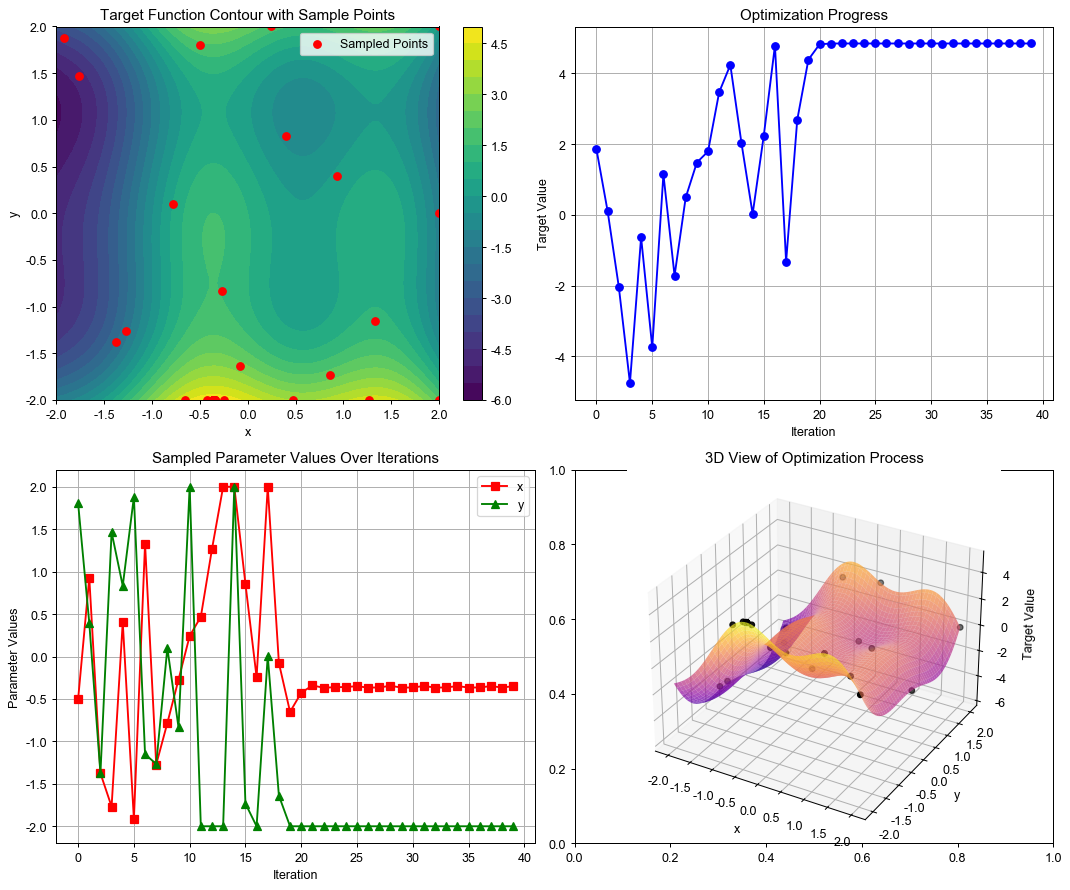

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from bayes_opt import BayesianOptimization

# 目标函数（复杂的非凸函数）
def black_box_function(x, y):
    return -np.sin(3*x) - x**2 + 0.7*x + np.cos(2*y) + y**2 - 0.5*y

# 定义贝叶斯优化的边界
pbounds = {'x': (-2, 2), 'y': (-2, 2)}

# 初始化贝叶斯优化器
optimizer = BayesianOptimization(
    f=black_box_function, 
    pbounds=pbounds,
    random_state=42
)

# 运行优化
optimizer.maximize(init_points=10, n_iter=30)

# 获取优化历史
x_vals, y_vals, target_vals = [], [], []
for res in optimizer.res:
    x_vals.append(res["params"]["x"])
    y_vals.append(res["params"]["y"])
    target_vals.append(res["target"])

# 生成虚拟数据进行可视化
x_range = np.linspace(-2, 2, 100)
y_range = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = black_box_function(X, Y)

# 绘图
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. 目标函数等高线 + 采样点分布
ax1 = axes[0, 0]
c = ax1.contourf(X, Y, Z, levels=20, cmap='viridis')
fig.colorbar(c, ax=ax1)
ax1.scatter(x_vals, y_vals, c='red', marker='o', label='Sampled Points')
ax1.set_title('Target Function Contour with Sample Points')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend()

# 2. 优化目标值的变化趋势
ax2 = axes[0, 1]
ax2.plot(range(len(target_vals)), target_vals, marker='o', linestyle='-', color='b')
ax2.set_title('Optimization Progress')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Target Value')
ax2.grid()

# 3. 采样点 x, y 的变化趋势
ax3 = axes[1, 0]
ax3.plot(range(len(x_vals)), x_vals, marker='s', linestyle='-', label='x', color='r')
ax3.plot(range(len(y_vals)), y_vals, marker='^', linestyle='-', label='y', color='g')
ax3.set_title('Sampled Parameter Values Over Iterations')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Parameter Values')
ax3.legend()
ax3.grid()

# 4. 采样点分布的 3D 视图
from mpl_toolkits.mplot3d import Axes3D
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.plot_surface(X, Y, Z, cmap='plasma', alpha=0.7)
ax4.scatter(x_vals, y_vals, target_vals, c='black', marker='o')
ax4.set_title('3D View of Optimization Process')
ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.set_zlabel('Target Value')

plt.tight_layout()
plt.show()

1. **目标函数定义**：使用一个非凸黑盒函数进行优化。
2. **贝叶斯优化**：用 `BayesianOptimization` 在 `(-2, 2) × (-2, 2)` 范围内优化。

![原文参考图，当前结果见代码输出](attachments/img_001.png)

- **等高线+采样点** (目标函数的形状 + 采样点分布)。
- **优化目标值趋势** (每次迭代的最优值变化)。
- **采样点趋势** (x, y 参数随迭代变化)。
- **3D 视图** (目标函数的 3D 形态 + 采样点)。

## 模型分析

### 优点

1. **高效的超参数优化**

   - 传统的 **网格搜索（Grid Search）** 需要穷举所有参数组合，计算量巨大。
   - **贝叶斯优化（Bayesian Optimization）** 通过 **高斯过程（GP）建模**，利用**过去的信息**来选择下一个评估点，减少不必要的计算，收敛更快。
2. **适用于计算代价高的模型**

   - 例如 XGBoost 训练时间较长，网格搜索不现实，**贝叶斯优化能减少训练次数，提高效率**。
3. **自动平衡探索（Exploration）和开发（Exploitation）**

   - 使用**期望改进（EI）** 或 **上置信界（UCB）** 采样策略，智能搜索最优参数，而不是盲目搜索。
4. **适用于连续和离散的超参数**

   - 例如 `learning_rate`（连续值）和 `max_depth`（离散整数）都能优化，不需要手动调整参数搜索范围。

### 缺点

1. **难以处理高维度参数空间**

   - 当优化的参数 **> 20 维** 时，高斯过程回归（GP）拟合困难，计算开销变大。
   - 可能需要使用 **基于树的贝叶斯优化（TPE: Tree-structured Parzen Estimator）** 作为替代。
2. **不适用于快速变化的目标函数**

   - **假设目标函数平滑（如 MSE）**，如果目标函数变化剧烈（如二分类问题中的 AUC），贝叶斯优化可能表现不佳。
3. **无法并行计算**

   - 贝叶斯优化每次基于过去的结果决定下一个搜索点，因此 **不适用于并行超参数搜索**，如 **随机搜索（Random Search）** 可以同时评估多个参数。

### 贝叶斯优化 vs. 其他优化算法

| 方法 | 适用场景 | 优势 | 劣势 |
|-|-|-|-|
| **网格搜索（Grid Search）** | **低维参数（<5）** | **确定性搜索**，找到全局最优解 | 计算量巨大，维度增加时不可行 |
| **随机搜索（Random Search）** | **参数维度较大（>10）** | 可并行计算，不依赖目标函数形状 | 搜索效率低，不能利用历史信息 |
| **贝叶斯优化（Bayesian Optimization）** | **高成本模型（如 XGBoost, 神经网络）** | **智能搜索**，减少计算次数 | **高维参数空间表现不佳** |
| **TPE（Tree-structured Parzen Estimator）** | **高维超参数搜索（>20）** | 适用于复杂搜索空间，支持分类变量 | 对连续变量优化效果略逊于贝叶斯优化 |
| **进化算法（Genetic Algorithm）** | **不连续、复杂目标函数** | 适用于离散变量和非凸函数 | 计算成本高，需要大量评估 |
| **梯度优化（Gradient-based Optimization）** | **可微目标函数（如深度学习）** | 适用于神经网络的超参数调整 | 需要计算梯度，不适用于 XGBoost |

### 什么时候使用贝叶斯优化？

**首选贝叶斯优化的情况**：

- **模型训练时间长（>10 秒）**：如 XGBoost、神经网络。
- **参数维度适中（5-20 维）**：比网格搜索更高效，比随机搜索更智能。
- **目标函数平滑（如 MSE、RMSE）**：适用于优化连续变量的损失函数。
- **需要自动化超参数搜索**：如 AutoML、机器学习平台。

**可以考虑其他方法的情况**

- **参数较少（<5 维）**：直接用网格搜索即可。
- **可以并行计算**：随机搜索可以同时训练多个模型，适用于大规模计算集群。
- **参数维度过高（>20 维）**：TPE 或进化算法可能表现更好。

## 最后

**贝叶斯优化在计算资源有限、超参数较多且训练时间较长的情况下是一个优选方法。**

但如果参数维度过高或目标函数波动剧烈，**可以考虑 TPE、随机搜索或进化算法**。